In [1]:
2+1

3

In [5]:
from research_analysis_generation.logger.custom_logger import CustomLogger

logger = CustomLogger().get_logger()
logger.info("upload")

{"timestamp": "2026-04-29T07:05:01.609594Z", "level": "info", "event": "upload"}


In [2]:
from typing import TypedDict, List
from pydantic import Field, BaseModel

In [3]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [27]:
class Analyst(BaseModel):
    name: str = Field(description="name of the analyst")
    role: str = Field(description="role of the analyst")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name} \n Role: {self.role}"

In [28]:
analyst = Analyst(
    name="Megha U",
    role="AI Engineer"
)

In [25]:
print(analyst)

name='Megha U' role='AI Engineer'


In [29]:
analyst.persona

'Name: Megha U \n Role: AI Engineer'

In [55]:
analyst.name

'Linda Kim'

In [9]:
class Perspective(BaseModel):
    analysts: List[Analyst] = Field(description="list of analysts")

In [8]:
class GenerateState(TypedDict):
    topic: str
    max_analyst: int 
    human_feedback: str 
    analysts: List[Analyst] 

In [7]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analyst} themes.

5. Assign one analyst to each theme."""

In [10]:
from research_analysis_generation.utils.model_loader import ModelLoader

model_loader = ModelLoader()
llm = model_loader.load_llm()

{"timestamp": "2026-04-29T16:22:43.992021Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-04-29T16:22:43.993504Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-04-29T16:22:43.994036Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"config_keys": ["embedding_model", "llm", "retriever", "chunking"], "timestamp": "2026-04-29T16:22:43.999409Z", "level": "info", "event": "YAML configuration loaded successfully"}
{"provider": "openai", "model": "gpt-4o-mini", "timestamp": "2026-04-29T16:22:44.000701Z", "level": "info", "event": "Loading LLM"}
{"provider": "openai", "model": "gpt-4o-mini", "timestamp": "2026-04-29T16:22:44.003590Z", "level": "info", "event": "LLM loaded successfully"}


In [6]:
llm.invoke("hi").content

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'Hello! How can I assist you today?'

In [17]:
def create_analyst(state:GenerateState):
    topic = state.get("topic")
    max_analyst = state.get("max_analyst")
    human_feedback = state.get("human_feedback")
    
    structured_llm = llm.with_structured_output(Perspective)
      
    system_message = analyst_instructions.format(
        topic = topic,
        max_analyst = max_analyst,
        human_feedback = human_feedback
    )
    
    analysts = structured_llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content="Generate the set of analysts.")])
    
    return {"analysts": analysts.analysts}

In [19]:
create_analyst(
    {
        'topic': 'health',
        'max_analysts': 1,
        'human_analyst_feedback': 'give the real info'}
    )


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Emily Carter', role='Public Health Analyst'),
  Analyst(name='James Thompson', role='Healthcare Data Scientist'),
  Analyst(name='Sarah Patel', role='Mental Health Researcher'),
  Analyst(name='Dr. Michael Chen', role='Epidemiologist'),
  Analyst(name='Laura Gomez', role='Health Policy Analyst')]}

In [34]:
def human_feedback(state: GenerateState):
    """No interruption"""
    pass

In [31]:
from langgraph.graph import START, END, StateGraph

In [32]:
def should_continue(state: GenerateState):
    feedback = (state.get("human_feedback") or "").strip().lower()
    
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [35]:
state_graph = StateGraph(GenerateState)
state_graph.add_node("create_analyst", create_analyst)
state_graph.add_node("human_feedback", human_feedback)

state_graph.add_edge(START, "create_analyst")
state_graph.add_edge("create_analyst", "human_feedback")

state_graph.add_conditional_edges("human_feedback",
                                  should_continue,
                                  ["create_analyst", END])

In [36]:
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
memory = MemorySaver()
graph = state_graph.compile(interrupt_before=["human_feedback"], checkpointer=memory)

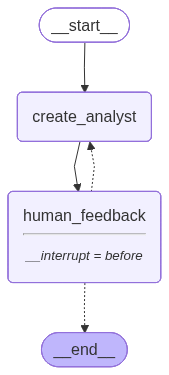

In [39]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [42]:
topic = "the benefits of adopting Langgraph as an agent framework"
max_analyst = 3
thread = {
    "configurable": {
        "thread_id":1
    }
}

In [44]:
for event in graph.stream(
    {
        "topic":topic,
        "max_analysts":max_analyst
    },
    thread,
    stream_mode= "values"):
    
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print("\n")
    

Name: Dr. Emily Chen
Role: AI Framework Specialist


Name: Mark Thompson
Role: Data Integration Expert


Name: Sarah Patel
Role: User Experience Analyst


Name: James Rodriguez
Role: Performance Optimization Consultant


Name: Linda Kim
Role: Security and Compliance Advisor




HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Role: AI Framework Specialist


Name: Mark Thompson
Role: Data Integration Expert


Name: Sarah Patel
Role: User Experience Analyst


Name: James Rodriguez
Role: Performance Optimization Consultant


Name: Linda Kim
Role: Security and Compliance Advisor




In [45]:
state = graph.get_state(thread)

In [46]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist'), Analyst(name='Mark Thompson', role='Data Integration Expert'), Analyst(name='Sarah Patel', role='User Experience Analyst'), Analyst(name='James Rodriguez', role='Performance Optimization Consultant'), Analyst(name='Linda Kim', role='Security and Compliance Advisor')]}, next=('human_feedback',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143f79-9f2a-6d92-8004-c612cff4e7fe'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-04-29T18:16:54.399707+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f143f79-83a4-67c6-8003-fc784acc8369'}}, tasks=(PregelTask(id='6909b42f-af7a-1c61-02cc-5f1ebf6e142c', name='human_feedback', path=('__pregel_pull', 'human_feedback'), error=None, interrupts=(), state=None, result=None),), 

In [47]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist'),
  Analyst(name='Mark Thompson', role='Data Integration Expert'),
  Analyst(name='Sarah Patel', role='User Experience Analyst'),
  Analyst(name='James Rodriguez', role='Performance Optimization Consultant'),
  Analyst(name='Linda Kim', role='Security and Compliance Advisor')]}

In [48]:
state.next

('human_feedback',)

In [49]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f143f78-b0b3-6858-bfff-d01e7dd0f6a3': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-04-29T18:16:29.394731+00:00\xa2id\xd9$1f143f78-b0b3-6858-bfff-d01e7dd0f6a3\xb0channel_versions\x81\xa9__start__\xd9400000000000000000000000000000001.0.17595868329167463\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f143f78-b0bb-6b52-8000-6cedddb4d343': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-04-29T18:16:29.398085+00:00\xa2id\xd9$1f143f78-b0bb-6b52-8000-6cedddb4d343\xb0channel_versions\x83\xa9__start__\xd9400000000000000000000000000000002.0.32495174709136465\xa5topic\xd9400000000000000000000000000000002.0.32495174709136465\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.32495174709136465\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start__\xd9400000000000000000000000000000001.0.17595868329167463\xb0updated_ch

In [50]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f143f79-9f2a-6d92-8004-c612cff4e7fe'}}

In [51]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f143f7f-7a14-6a84-8005-166ef1108b44'}}

In [52]:
for event in graph.stream(
    {
        "topic":topic,
        "max_analysts":max_analyst
    },
    thread,
    stream_mode= "values"):
    
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print("\n")

Name: Dr. Emily Chen
Role: AI Framework Specialist


Name: Mark Thompson
Role: Data Integration Expert


Name: Sarah Patel
Role: User Experience Analyst


Name: James Rodriguez
Role: Performance Optimization Consultant


Name: Linda Kim
Role: Security and Compliance Advisor




HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Role: AI Framework Specialist


Name: Mark Thompson
Role: Data Integration Expert


Name: Sarah Patel
Role: User Experience Analyst


Name: James Rodriguez
Role: Performance Optimization Consultant


Name: Linda Kim
Role: Security and Compliance Advisor




In [53]:
state.next

('human_feedback',)

In [54]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist'),
  Analyst(name='Mark Thompson', role='Data Integration Expert'),
  Analyst(name='Sarah Patel', role='User Experience Analyst'),
  Analyst(name='James Rodriguez', role='Performance Optimization Consultant'),
  Analyst(name='Linda Kim', role='Security and Compliance Advisor')]}

## Second Workflow

In [ ]:
#Search web give information form this Tavily
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")
tavily_search = TavilySearchResults()

In [80]:
tavily_search.invoke("langchain")

[{'title': 'What Is LangChain? | IBM',
  'url': 'https://www.ibm.com/think/topics/langchain',
  'content': '# What is LangChain?\n\n## Authors\n\nDave Bergmann \n\nSenior Staff Writer, AI Models\n\nIBM Think\n\nCole Stryker \n\nStaff Editor, AI Models\n\nIBM Think\n\n## LangChain overview\n\nLangChain is an open source orchestration framework for application development using large language models (LLMs). Available in both Python- and Javascript-based libraries, LangChain’s tools and APIs simplify the process of building LLM-driven applications like chatbots and AI agents. [...] LangChain is essentially a library of abstractions for Python and Javascript, representing common steps and concepts necessary to work with language models. These modular components—like functions and object classes—serve as the building blocks of generative AI programs. They can be “chained” together to create applications, minimizing the amount of code and fine understanding required to execute complex NLP ta

In [79]:
from langchain_community.document_loaders import WikipediaLoader

docs = WikipediaLoader(query="Langchain").load()
print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 


In [81]:
from typing import Annotated
import operator
from langgraph.graph import MessagesState

#create pydantic model
class InterviewState(MessagesState):
    max_num_turns:int 
    context: Annotated[list, operator.add]
    analyst: Analyst
    interview_transcript: str
    sections: list
    
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="search query for retrieval.")

In [83]:
question_instustion = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [86]:
question_instustion.format(goals=analyst)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: name=\'Linda Kim\' role=\'Security and Compliance Advisor\'\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goals provided to you.'

In [87]:
def generate_question(state: InterviewState):
    """Node to generate question"""
    analyst = state["analyst"]
    messages = state["messages"]
    
    system_message = question_instustion.format(goals=analyst)
    
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    return {"messages": [question]}

In [90]:
from langchain_core.messages import get_buffer_string

search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")


In [91]:
def search_web(state: InterviewState):
    """
    Fetch data from the web
    """
    
    str_llm = llm.with_structured_output(SearchQuery)
    search_query = str_llm.invoke([search_instructions]+state["messages"])
    
    searched_docs = tavily_search.invoke(search_query.search_query)
    
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in searched_docs
        ]
    )

    return {"context": [formatted_search_docs]}
    

In [ ]:

def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    search_docs = WikipediaLoader(query=search_query.search_query).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 


In [94]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""


In [95]:
def generate_answer(state:InterviewState):
    
    """ Node to answer a question """
   
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    answer.name = "expert"
    
    return {"messages": [answer]}

In [96]:
def save_answer(state: InterviewState):
    """ Save interviews """

    messages = state["messages"]
    interview = get_buffer_string(messages)
    
    return {"interview": interview}

In [99]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [103]:
def write(state: InterviewState):
    """ Node to answer a question """
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    return {"sections": [section.content]}

In [ ]:
def route_messages(state: InterviewState, name: str = "expert"):
    """ Route between question and answer """
    
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns', 2)

    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    if num_responses >= max_num_turns:
        return 'save_answer'

    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_answer'
    
    return "ask_question"

In [104]:
builder = StateGraph(InterviewState)
builder.add_node("generate_question", generate_question)
builder.add_node("search_web", search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)
builder.add_node("save_data", save_answer)
builder.add_node("write_section", write)

builder.add_edge(START, "generate_question")
builder.add_edge("generate_question", "search_web")
builder.add_edge("generate_question", "search_wikipedia")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_conditional_edges("generate_answer", route_messages, ["generate_question", "save_data"])
builder.add_edge("save_data", "write_section")
builder.add_edge("write_section", END)

In [105]:
graph_builder = builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

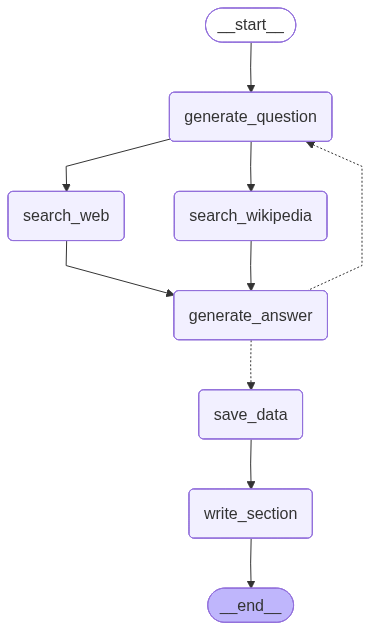

In [107]:
from IPython.display import Image, display

display(Image(graph_builder.get_graph(xray=1).draw_mermaid_png()))

In [110]:
state = {"max_num_turns":2,
         "context":[],
         "analyst":analyst,
         "interview":"","section":[],
         "messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [ ]:
result = generate_question(state)
result.messages

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'messages': [AIMessage(content="Hello, my name is Alex Carter, and I'm an analyst focused on security and compliance. I'm excited to speak with you today, Linda. Your expertise in this field is invaluable, and I’d love to dive into some specific insights you might have.\n\nTo start, could you share an example of a surprising trend you've noticed in security compliance over the past year? Something that might not be on everyone's radar?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 181, 'total_tokens': 262, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_43b64008fd', 'id': 'chatcmpl-DaPe8hu4E4rnNWOH9hntsOkdTj1CY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--151a

In [ ]:
for message in result.get("messages"):
    print(message)
    print("\n")


content="Hello, my name is Alex Carter, and I'm an analyst focused on security and compliance. I'm excited to speak with you today, Linda. Your expertise in this field is invaluable, and I’d love to dive into some specific insights you might have.\n\nTo start, could you share an example of a surprising trend you've noticed in security compliance over the past year? Something that might not be on everyone's radar?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 181, 'total_tokens': 262, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_43b64008fd', 'id': 'chatcmpl-DaPe8hu4E4rnNWOH9hntsOkdTj1CY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--151a06a2-5e22-47a2-a0a8-b10fd75

In [120]:
result["messages"][0].content

"Hello, my name is Alex Carter, and I'm an analyst focused on security and compliance. I'm excited to speak with you today, Linda. Your expertise in this field is invaluable, and I’d love to dive into some specific insights you might have.\n\nTo start, could you share an example of a surprising trend you've noticed in security compliance over the past year? Something that might not be on everyone's radar?"

In [122]:
result = search_web(state)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [126]:
print(result.get("context")[0])

<Document href="https://www.driveresearch.com/market-research-company-blog/tech-market-research/"/>
## Best Practices for Conducting Tech Market Research

Set clear objectives

Tech firms should approach market research with clear objectives.

Conducting research is far easier when a team has its goals lined up prior to even partnering with a third-party research firm. Common goals for tech companies include evaluating customer needs, market trends, and competitor trends.

Prioritize data quality

Secondly, data quality must be prioritized. Data accuracy plays a key role in all research, of course, and plays the ultimate role in how tech companies end up using it.

To ensure quality data, firms should use standardized survey instruments, validate responses, and employ statistical techniques to review the feedback.

Utilizing a combination of qualitative and quantitative methods [...] ## Mitigating Risks

By conducting market research, tech companies can proactively identify and plan fo

## Third Workflpw